# Lab Session 2 - Data Preparation

**Rename** this file: add you first name at the end of the file.

## Load libaries

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline



from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

## Load the dataset
Description of Titanic dataset: https://nannyml.readthedocs.io/en/v0.13.1/datasets/titanic.html

Note: The reason to use `df = titanic.frame.copy()` is to backup the original data file at `titanic`, and you only modify `df` in the later steps.

In [91]:
# Load Titanic from OpenML
titanic = fetch_openml(name="titanic", version=1, as_frame=True, parser='auto')
df = titanic.frame.copy()

# Display dataset size and first few rows
print('Dataset size:', df.shape)
df.head()

Dataset size: (1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [92]:
# Which features are numerical vs categorical?
df.info()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print('Numerical:', num_cols)
print('Categorical:', cat_cols)

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   str     
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   str     
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    str     
 10  embarked   1307 non-null   category
 11  boat       486 non-null    str     
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    str     
dtypes: category(3), float64(3), int64(3), str(5)
memory usage: 116.6 KB
Numerical: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'body']
Categorical: ['survived', 'name', 'sex', 'ticket', 'cabin', 'embarked', 'boat', 'home.dest']


## Data preprocessing
Find missing values, duplicates, and list columns to consider dropping.

In [93]:
# We want our target variable to be numeric
df['survived'] = df['survived'].astype(int)

In [73]:
# Drop meaningless columns
df = df.drop(columns=['name', 'ticket', 'boat', 'body', 'home.dest'], errors='ignore')


In [74]:
# Missing values and duplicates
display(df.isnull().sum())
print('Duplicate rows:', df.duplicated().sum())

pclass         0
survived       0
sex            0
age          263
sibsp          0
parch          0
fare           1
cabin       1014
embarked       2
dtype: int64

Duplicate rows: 185


In [75]:
# Deal with missing values and duplicates

# sklearn
imputer = SimpleImputer(strategy='median')
df['age'] = imputer.fit_transform(df[['age']])
df['fare'] = imputer.fit_transform(df[['fare']])

# Pandas
df = df.fillna({'embarked': df['embarked'].mode()[0]})
df = df.drop_duplicates(keep='first')

# Cabin has too many missing values, classify as 'Unknown'
df['cabin'] = df['cabin'].fillna('Unknown')
df

,pclass,survived,sex,age,sibsp,parch,fare,cabin,embarked
0,1,1,female,29.0000,0,0,211.3375,B5,S
1,1,1,male,0.9167,1,2,151.5500,C22 C26,S
2,1,0,female,2.0000,1,2,151.5500,C22 C26,S
3,1,0,male,30.0000,1,2,151.5500,C22 C26,S
4,1,0,female,25.0000,1,2,151.5500,C22 C26,S
...,...,...,...,...,...,...,...,...,...
1303,3,0,male,28.0000,0,0,14.4583,Unknown,C
1304,3,0,female,14.5000,1,0,14.4542,Unknown,C
1306,3,0,male,26.5000,0,0,7.2250,Unknown,C
1307,3,0,male,27.0000,0,0,7.2250,Unknown,C


## Visualisations
- Age distribution
- Age and Fare distributions grouped by survival
- Counts of `pclass` grouped by survival (pivot table)

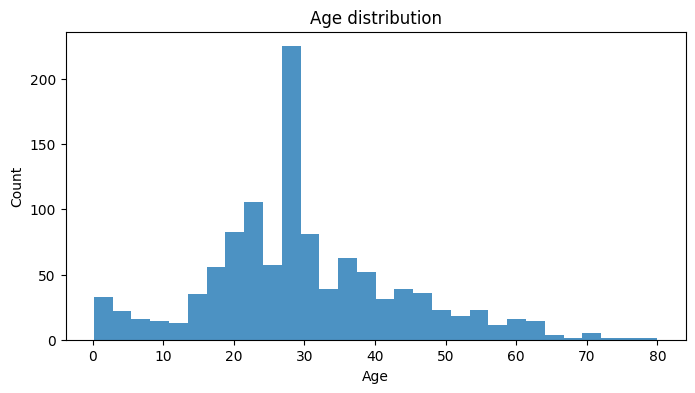

In [76]:
# Age distribution
plt.figure(figsize=(8,4))
plt.hist(df['age'], bins=30, color='C0', alpha=0.8)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

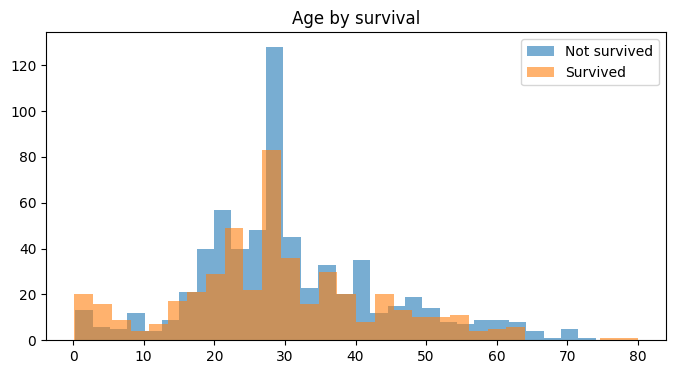

In [77]:
# Age distribution by survived
plt.figure(figsize=(8,4))
for s, label in zip([0,1], ['Not survived','Survived']):
    subset = df[df['survived']==s]
    plt.hist(subset['age'], bins=30, alpha=0.6, label=label)
plt.legend()
plt.title('Age by survival')
plt.show()

<Figure size 800x400 with 0 Axes>

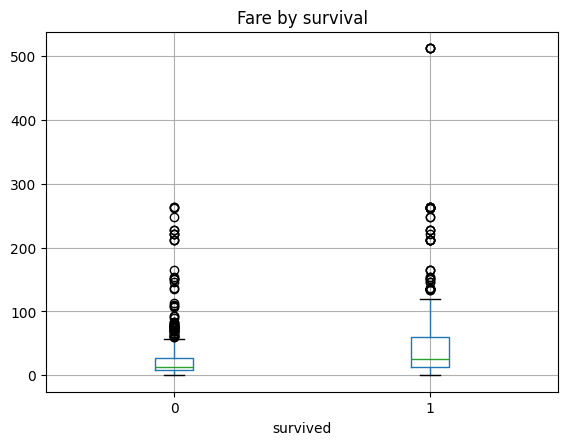

In [78]:
# Fare by survival (boxplot)
plt.figure(figsize=(8,4))
df.boxplot(column='fare', by='survived')
plt.title('Fare by survival')
plt.suptitle('')
plt.show()

In [79]:
# pclass counts pivot table
if set(['survived','pclass']).issubset(df.columns):
    print(df.pivot_table(index='survived', columns='pclass', aggfunc='size'))

pclass      1    2    3
survived               
0         121  130  400
1         199  113  156


# Encoding categorical features

Refer to https://scikit-learn.org/stable/modules/preprocessing.html

**Ordinal Encoder:** This estimator transforms each categorical feature to one new feature of integers (0 to n_categories - 1)

**One-Hot Encoder:** It transforms each categorical feature with n_categories possible values into n_categories binary features, with one of them 1, and all others 0.

In [80]:
# You can try both Ordinary Encoding and One-Hot Encoding
enc_cols = ['sex', 'cabin', 'embarked']
ord_enc = OrdinalEncoder()
df_ord_enc = df.copy()
df_ord_enc[enc_cols] = ord_enc.fit_transform(df_ord_enc[enc_cols])
df_ord_enc.head()

,pclass,survived,sex,age,sibsp,parch,fare,cabin,embarked
0,1,1,0.0,29.0000,0,0,211.3375,43.0,2.0
1,1,1,1.0,0.9167,1,2,151.5500,79.0,2.0
2,1,0,0.0,2.0000,1,2,151.5500,79.0,2.0
3,1,0,1.0,30.0000,1,2,151.5500,79.0,2.0
4,1,0,0.0,25.0000,1,2,151.5500,79.0,2.0


In [81]:
# We can see One-Hot Encoding increases the number of features very much
one_hot_enc = OneHotEncoder(drop='first', sparse_output=False)
df_one_hot_enc = df.copy()
one_hot_encoded = one_hot_enc.fit_transform(df_one_hot_enc[enc_cols])
one_hot_encoded_df = pd.DataFrame(one_hot_encoded, columns=one_hot_enc.get_feature_names_out(enc_cols), index=df_one_hot_enc.index)
df_one_hot_enc = pd.concat([df_one_hot_enc.drop(columns=enc_cols), one_hot_encoded_df], axis=1)
df_one_hot_enc.head()

,pclass,survived,age,sibsp,parch,fare,sex_male,cabin_A11,cabin_A14,cabin_A16,...,cabin_F G73,cabin_F2,cabin_F33,cabin_F38,cabin_F4,cabin_G6,cabin_T,cabin_Unknown,embarked_Q,embarked_S
0,1,1,29.0000,0,0,211.3375,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,1,0.9167,1,2,151.5500,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1,0,2.0000,1,2,151.5500,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,0,30.0000,1,2,151.5500,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1,0,25.0000,1,2,151.5500,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Split train/test

In [82]:
# Split train/test
X = df_ord_enc.drop(columns=['survived'])
y = df_ord_enc['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Train class distribution:')
print(y_train.value_counts())

Train shape: (895, 8) Test shape: (224, 8)
Train class distribution:
survived
0    521
1    374
Name: count, dtype: int64


## Handle class imbalance (if exists)
We check the ratio and demonstrate simple upsampling of the minority class if imbalance is large.

In [83]:
from sklearn.utils import resample
# Combine train for resampling
df_train = pd.concat([X_train, y_train], axis=1)
counts = y_train.value_counts()
ratio = counts.min() / counts.max() 
print('Class counts (train):')
print(counts)
if ratio < 0.5:
    majority = df_train[df_train['survived']==counts.idxmax()]
    minority = df_train[df_train['survived']==counts.idxmin()]
    minority_up = resample(minority, replace=True, n_samples=len(majority), random_state=42)
    df_bal = pd.concat([majority, minority_up])
    X_train_bal = df_bal.drop(columns=['survived'])
    y_train_bal = df_bal['survived']
    print('After upsampling:')
    print(y_train_bal.value_counts())
else:
    X_train_bal, y_train_bal = X_train, y_train

Class counts (train):
survived
0    521
1    374
Name: count, dtype: int64


## Normalize numerial features

Refer to: https://scikit-learn.org/stable/modules/preprocessing.html

In [84]:
# Normalize numerical features
scaler = StandardScaler()
num_features = X_train_bal.select_dtypes(include=[np.number]).columns.tolist()
X_train_bal[num_features] = scaler.fit_transform(X_train_bal[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])
print('Normalization complete. Example (first 5 rows):')
display(X_train_bal.head())

Normalization complete. Example (first 5 rows):


,pclass,sex,age,sibsp,parch,fare,cabin,embarked
340,-0.252045,-1.25373,-1.894826,1.579918,0.624989,0.054457,0.425842,0.616304
938,0.910740,0.79762,-0.872610,0.524674,0.624989,-0.524454,0.489236,0.616304
747,0.910740,0.79762,-2.162552,-0.530570,1.711135,-0.402787,0.489236,0.616304
693,0.910740,0.79762,-0.653563,-0.530570,-0.461157,-0.525075,0.489236,-0.593328
820,0.910740,0.79762,-1.529749,-0.530570,1.711135,-0.288940,0.489236,0.616304


# Homework
1. Do the `X_train` and `X_test` data suffer from **data leakage**? (just `print("yes/no")`)
1. **Impute** the missing values in `age` column using Pandas
2. Create a sub-dataframe containing only passengers from Pclass 3. 
3. Now the sub-data is unbalanced, use down-sampling to make this sub-data balanced. (Hint: use `pd.DataFrame.sample()` and set `random_state=myseed`) https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html
4. What is the mean of `age` in this resampled sub-data (round to 2 decimals)

In [85]:
print("no")


no


In [86]:
df['age'] = df['age'].fillna(df['age'].median())
df['age'].isnull().sum()



np.int64(0)

In [87]:
df_p3 = df[df['pclass'] == 3]
df_p3.head()


,pclass,survived,sex,age,sibsp,parch,fare,cabin,embarked
600,3,0,male,42.0,0,0,7.55,Unknown,S
601,3,0,male,13.0,0,2,20.25,Unknown,S
602,3,0,male,16.0,1,1,20.25,Unknown,S
603,3,1,female,35.0,1,1,20.25,Unknown,S
604,3,1,female,16.0,0,0,7.65,Unknown,S


In [88]:
myseed = 42

# Separate majority and minority
majority = df_p3[df_p3['survived'] == 0]
minority = df_p3[df_p3['survived'] == 1]

# Down-sample majority to match minority size
majority_down = majority.sample(n=len(minority), random_state=myseed)

# Combine balanced data
df_p3_bal = pd.concat([majority_down, minority])

df_p3_bal['survived'].value_counts()


survived
0    156
1    156
Name: count, dtype: int64

In [89]:
round(df_p3_bal['age'].mean(), 2)


np.float64(24.61)